# Parametric Tests

Parametric tests are statistical tools predicated on the assumption that the data adheres to a normal distribution. They facilitate inferences about population parameters based on sampled data.

## One-Sample Test

A one-sample test is employed when there's a single population of interest, and a solitary sample is extracted from it. It evaluates whether there's a notable discrepancy between the sample values and the population parameter.

## Two-Sample Test

The two-sample test enters the picture when samples are drawn from two distinct populations. It gauges whether the population parameters diverge significantly based on the sample statistics.

## Critical Test Statistic

The critical test statistic denotes the threshold value of the sample test statistic pivotal in discerning whether to embrace or repudiate the null hypothesis.

## Region of Rejection

The region of rejection delineates the spectrum of values wherein the null hypothesis is discarded. Conversely, the region of acceptance encompasses values where the null hypothesis holds sway.

## Types of Tests

Several types of tests are at our disposal:

+ **Z-tests**: Apt for ample sample sizes (n ≥ 30) with a known population standard deviation.
+ **T-tests**: Tailored for modest sample sizes (n < 30) with an unknown population standard deviation.
+ **F-tests**: Tasked with comparing values across more than two variables.
+ **Chi-square**: Devised for the comparison of categorical data.

## One-Tail Test (Directional Test)

A one-tail test enters the fray when probing for a change in the mean, armed with the knowledge of the change's direction.  

Two iterations of the one-tail test exist:

+ **Upper one-tail**: The region of rejection resides on the right tail. It's invoked when scrutinizing whether the mean score has surged.
+ **Lower one-tail**: The region of rejection graces the left tail. It's enlisted when assessing if the mean score has plummeted.

## Two-Tail Test (Non-Directional Test)

The two-tail test is deployed when scrutinizing a change in the mean sans knowledge of the direction. The region of rejection spans both tails of the distribution.

## The P-value

The p-value is the linchpin in deciding whether to embrace or eschew the null hypothesis. It's computed based on the sample data and juxtaposed with a significance level, usually 0.05. 
+ If p < 0.05, it intimates that the sample data is improbable to stem from randomness and doesn't mirror the population adequately. In such instances, the null hypothesis is jettisoned. 
+ If p > 0.05, it implies a heightened likelihood that the sample inadequately represents the population, prompting the null hypothesis's retention



  <center><img src="./data/hypothesis.png"/></center>

In [1]:
from scipy.stats import norm

z = 1.6448536269514722
p = 0.95

print("Calculating p given z: p = ", norm.cdf(z))
print("Calculating z given p: z = ", norm.ppf(p))

Calculating p given z: p =  0.95
Calculating z given p: z =  1.6448536269514722


# Choosing a statistical test?

Below is a simple diagram which shows how to choose a test depending on different data types.


<center><img src="./data/a1.png"/></center>


---
## When to Use Parametric vs Non-Parametric Tests

Parametric tests (z, t, ANOVA) assume the data follow a **normal distribution**.
The **Shapiro-Wilk test** checks this assumption. Below we demonstrate what a
normal distribution looks like vs a clearly non-normal one — and what the
normality test reports for each.

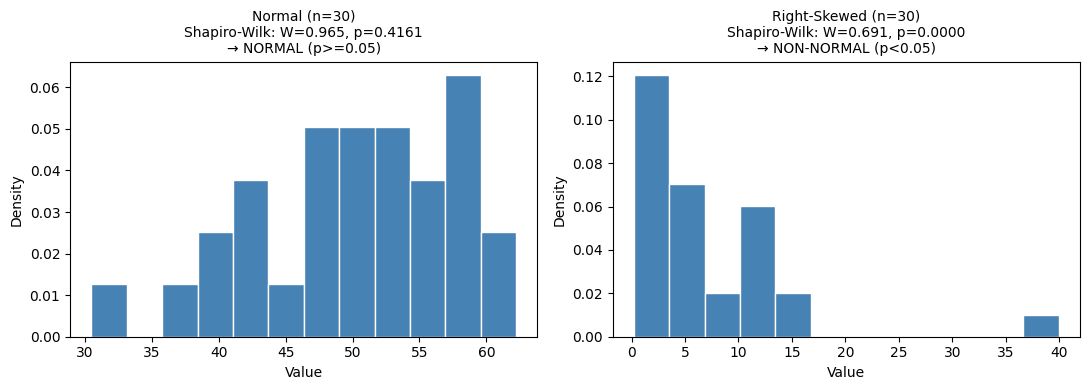

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)

normal  = rng.normal(loc=50, scale=10, size=30)
skewed  = rng.exponential(scale=10, size=30)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, label in [
    (axes[0], normal, 'Normal (n=30)'),
    (axes[1], skewed, 'Right-Skewed (n=30)'),
]:
    ax.hist(data, bins=12, color='steelblue', edgecolor='white', density=True)
    stat, p = stats.shapiro(data)
    verdict = 'NORMAL (p>=0.05)' if p >= 0.05 else 'NON-NORMAL (p<0.05)'
    ax.set_title(f'{label}\nShapiro-Wilk: W={stat:.3f}, p={p:.4f}\n→ {verdict}', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()


### Decision Guide: Parametric vs Non-Parametric

```
Is the data normally distributed (Shapiro-Wilk p >= 0.05 or n > 30 by CLT)?
│
├─ YES → Use parametric tests:
│         1 group vs value    → One-sample t-test (or z-test if σ known)
│         2 independent groups → Independent t-test (Welch's)
│         2 paired groups      → Paired t-test
│         3+ groups            → One-Way ANOVA → Tukey HSD post-hoc
│
└─ NO  → Use non-parametric tests:
          1 group vs value    → Wilcoxon signed-rank test
          2 independent groups → Mann-Whitney U test
          2 paired groups      → Wilcoxon signed-rank test
          3+ groups            → Kruskal-Wallis → Dunn's post-hoc
```

**Rule of thumb:** For n ≥ 30, the Central Limit Theorem makes t-tests and ANOVA
robust to mild non-normality. For n < 30 with strong skewness or outliers, prefer
the non-parametric route.

In [3]:
# Quick reference: Python implementations for all four decision paths
from scipy import stats
import numpy as np

rng = np.random.default_rng(seed=42)
x = rng.normal(50, 10, 20)
y = rng.normal(55, 10, 20)

print('Two independent groups — parametric vs non-parametric:')
t_stat, t_p   = stats.ttest_ind(x, y, equal_var=False)
u_stat, mw_p  = stats.mannwhitneyu(x, y, alternative='two-sided')

print(f'  Welch t-test         : t={t_stat:.3f}, p={t_p:.4f}')
print(f'  Mann-Whitney U       : U={u_stat:.1f}, p={mw_p:.4f}')
print()

a = rng.normal(50, 10, 20)
b = rng.normal(53, 10, 20)
c = rng.normal(57, 10, 20)

print('Three groups — parametric vs non-parametric:')
f_stat, f_p   = stats.f_oneway(a, b, c)
h_stat, kw_p  = stats.kruskal(a, b, c)

print(f'  One-Way ANOVA        : F={f_stat:.3f}, p={f_p:.4f}')
print(f'  Kruskal-Wallis       : H={h_stat:.3f}, p={kw_p:.4f}')


Two independent groups — parametric vs non-parametric:
  Welch t-test         : t=-2.437, p=0.0196
  Mann-Whitney U       : U=127.0, p=0.0499

Three groups — parametric vs non-parametric:
  One-Way ANOVA        : F=0.490, p=0.6154
  Kruskal-Wallis       : H=1.167, p=0.5580


---
## ML/AI Connection

- **Residual diagnostics:** after fitting a regression model, Shapiro-Wilk on residuals checks whether the normality assumption (required for valid t/F-tests in regression output) holds.
- **Sklearn's `SelectKBest`** uses parametric (F-test) or non-parametric (mutual information) feature scoring — choose based on normality.
- **Gaussian process regression** is a fully parametric probabilistic model that assumes normally distributed outputs.
